## Preparing iEEG data

In [2]:
ieegdir = '/path/to/ieeg/atlas/'

from scipy.io import loadmat
mat = loadmat(ieegdir + '/WakefulnessMatlabFile.mat')

In [3]:
tr, nchannels = mat['Data'].shape
sampfreq = int(mat['SamplingFrequency'].item())

In [4]:
bounds = {'delta': (2,4), \
          'theta': (5,7), \
          'alpha': (8, 12), \
          'beta': (15, 29), \
          'gamma1': (30, 59), \
          'gamma2': (60, 90)}

In [5]:
def compute_spectrum_w_holes(data, fs, window, nperseg, noverlap,plot):
    import matplotlib.pyplot as plt
    from scipy import signal
    
    f_axis,t_axis,spg = signal.spectrogram(data, fs, 'hann', nperseg, noverlap)
    psd_mean = spg[:,~np.all(spg==0, axis=0)].mean(1)
    psd_median = np.median(spg[:,~np.all(spg==0, axis=0)],axis=1)

    if plot: plt.plot(f_axis, psd_median); plt.show()
        
    return f_axis, psd_mean, psd_median

def calculate_bandpower(ts, sampfreq, bounds, relative=True, plot=False):
    '''
    array, float, tuple, bool (optional) -> float
    '''
    from scipy.integrate import simpson
    
    win = 1 * sampfreq
    f, _, pds_median = compute_spectrum_w_holes(data=ts, fs=sampfreq, nperseg=int(sampfreq), window=win, noverlap=int(sampfreq/2), plot=plot)
    
    low, high = bounds
    idx_fband = np.logical_and(f >= low, f <= high)
    f_res = f[1] - f[0]

    bandpower = simpson(pds_median[idx_fband], dx=f_res)
    
    if relative:
        totalpower = simpson(pds_median, dx=f_res)
        rel_bandpower = bandpower / totalpower
        return rel_bandpower

    return bandpower

In [6]:
import pandas as pd
import numpy as np
bandpowers = pd.DataFrame( np.zeros((nchannels, len(bounds))), columns = bounds.keys())

for chi in range(nchannels):
    for fband in bounds.keys():
        ts = mat['Data'][:,chi]
        bp = calculate_bandpower(ts=ts, sampfreq=200, bounds=bounds[fband], relative=True, plot=False)
        
        #print(fband + ':' + str(bp))
        bandpowers.at[chi, fband] = bp
    

In [7]:
from scipy.stats import zscore

bandpowers_z = zscore(bandpowers, axis = 1)

In [8]:
mni_coords = mat['ChannelPosition']

In [9]:
import pyvista as pv
eeg = pv.PolyData(mni_coords)

In [10]:
for fband in bandpowers_z.columns:
    eeg[fband] = bandpowers_z[fband]

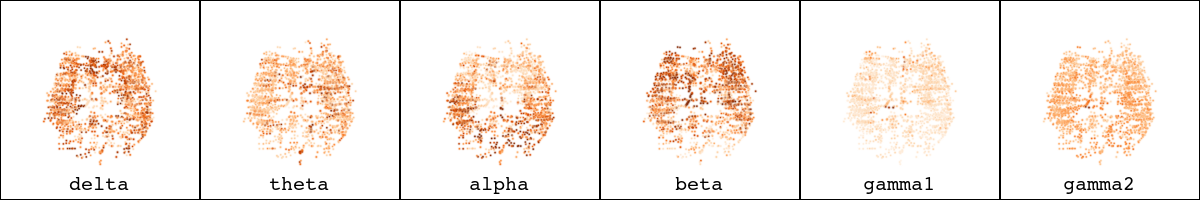

In [11]:
import copy
import pyvista as pv

pl = pv.Plotter(shape=(1, 6), window_size = (1200, 200))

for fi, fband in enumerate(bandpowers.columns):
    pl.subplot(0,fi)

    tmp = copy.copy(eeg)
    pl.add_points(tmp, scalars = fband, style = 'points_gaussian', cmap = 'Oranges', show_scalar_bar=False)
    pl.add_text(fband, font = 'courier', position = 'lower_edge', font_size = 9)
    pl.camera_position = 'xy'
pl.show(jupyter_backend='static')

# Only keep the left hemisphere

In [12]:
left_channel_ind = np.where( eeg.points[:,0] < 0)[0]

In [13]:
left_eeg = pv.PolyData(eeg.points[left_channel_ind,:])

In [14]:
for fband in bandpowers_z.columns:
    left_eeg[fband] = bandpowers_z[fband][left_channel_ind]

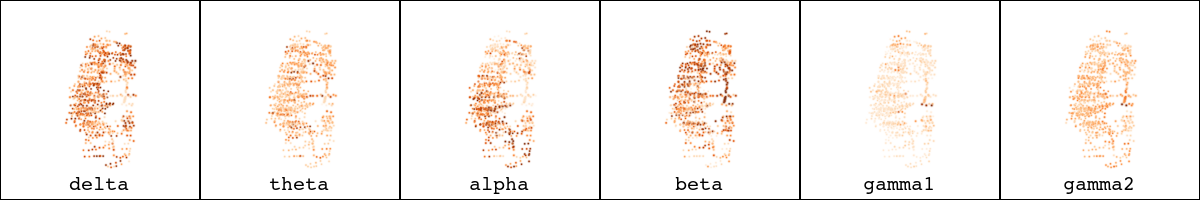

In [15]:
import copy
import pyvista as pv

pl = pv.Plotter(shape=(1, 6), window_size = (1200, 200))

for fi, fband in enumerate(bandpowers.columns):
    pl.subplot(0,fi)

    tmp = copy.copy(left_eeg)
    pl.add_points(tmp, scalars = fband, style = 'points_gaussian', cmap = 'Oranges', show_scalar_bar=False)
    pl.add_text(fband, font = 'courier', position = 'lower_edge', font_size = 9)
    pl.camera_position = 'xy'
pl.show(jupyter_backend='static')

## Remove outliers

In [16]:
from config import *

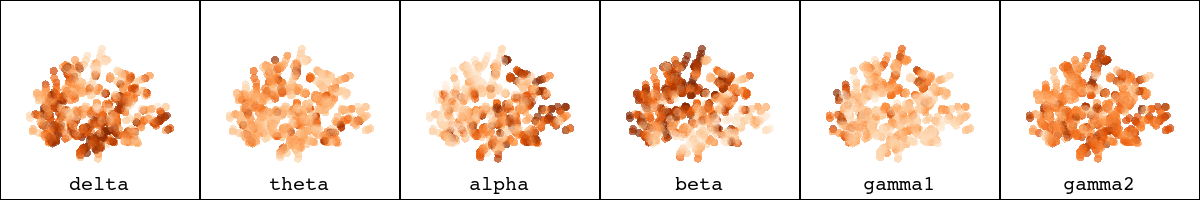

In [23]:
fbands = bandpowers.columns

outlier_inds = dict.fromkeys(fbands)

pl = pv.Plotter(shape=(1,6), window_size = (1200,200))

for fi, fband in enumerate( fbands ):

    distr = zscore( left_eeg[fband] )
    
    retain_ind = np.where(abs(distr) < 3)[0]
    remove_ind = np.where(abs(distr) >= 3)[0]

    outlier_inds[fband] = remove_ind

    new_no_outlier = pv.PolyData(left_eeg.points[retain_ind,:])
    new_no_outlier[fband + '_zscored_no_outlier'] = left_eeg[fband][retain_ind]

    import joblib
    import nibabel as nb
    from nibabel.affines import apply_affine
    import numpy as np
    import numpy.linalg as npl
    import os
    from scipy.ndimage import map_coordinates
    
    reregistered_pet_dir = '/path/to/outputs/from/volume/coregistration/' # this is the output directory of volume_data_coregistration.sh
    
    fnames = os.listdir(reregistered_pet_dir)
    
    for fname in fnames:
        PET = nb.load(reregistered_pet_dir + fname)
    
        sourcetag = fname.split('_')[0].split('-')[1]
        desctag = fname.split('_')[1].split('-')[1]
    
        maptag = f'pet_{sourcetag}_{desctag}'
    
        points = new_no_outlier.points
        img_data = PET.get_fdata()
        inverse_aff = npl.inv(PET.affine)
        ijk_points = apply_affine(inverse_aff, points)
    
        vals = np.zeros(new_no_outlier.n_points)
        for pi in range(points.shape[0]):
            
            vox_value = map_coordinates(img_data, ijk_points[pi,:].reshape(-1,1), order=1)
            vals[pi] = vox_value[0]
            
        new_no_outlier[maptag] = vals

    pl.subplot(0, fi)
    pl.add_points(new_no_outlier.rotate_z(180), scalars = fband + '_zscored_no_outlier', point_size = 8,\
                  cmap = 'Oranges', opacity = 0.7, show_scalar_bar=False, \
                  **point_aes)
    pl.add_text(fband, font = 'courier', position = 'lower_edge', font_size = 9)
    pl.camera_position = 'yz'

    joblib.dump(new_no_outlier, projdir + f'/data/icbm09c_left-volume_ieeg-{fband}-pet.pkl')
    
pl.show(jupyter_backend = 'static')